# ASSIGNMENT 1 Q2

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

df = pd.read_csv("silver.csv")
train_size = int(len(df) * 0.8)
tscv = TimeSeriesSplit(n_splits=10)


## ARIMA-GARCH models

In [19]:
return_rate = 100*df["target_return"].dropna()
train = return_rate.iloc[:train_size]
test = return_rate.iloc[train_size:]

In [3]:
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
import itertools

p-value: 1.7931843261586577e-29
      lb_stat  lb_pvalue
5    8.476003   0.131880
10  15.516697   0.114329
15  19.531402   0.190655


<Figure size 1200x600 with 0 Axes>

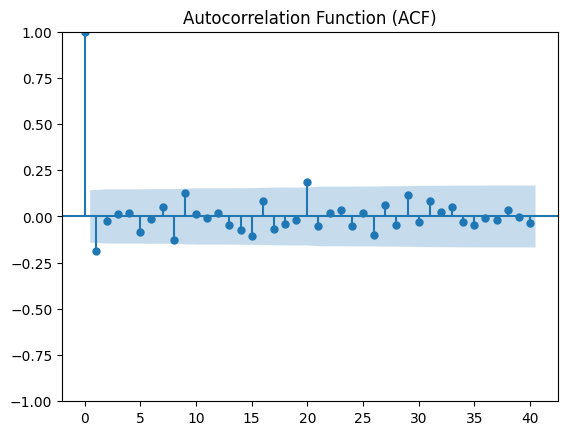

<Figure size 1200x600 with 0 Axes>

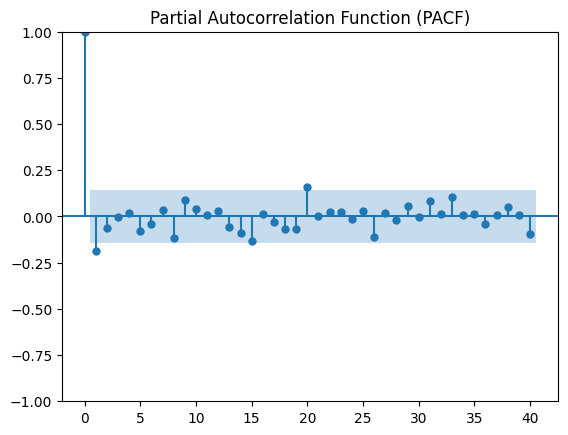

In [4]:
# Perform Augmented Dickey-Fuller test
result = adfuller(train)
print("p-value:", result[1])
# The timeseries appears to be stationary based on the ADF test. We can proceed with modeling the returns.

ljung_box_result = acorr_ljungbox(train, lags=[5, 10, 15], return_df=True)
print(ljung_box_result)
# Not white noise, fit ARMA to the returns.

# Plot ACF
plt.figure(figsize=(12,6))
plot_acf(train, lags=40)   # up to 40 lags
plt.title("Autocorrelation Function (ACF)")
plt.show()

# Plot PACF
plt.figure(figsize=(12,6))
plot_pacf(train, lags=40, method="ywm")  # Yule-Walker method
plt.title("Partial Autocorrelation Function (PACF)")
plt.show()

### Mean model
#### Training

In [20]:
cv_ARIMA = []
lags = [(0,0,0),(1,0,0),(0,0,1),(1,0,1)]

for spec in lags:
    mean_fold_errors = []

    for train_idx, val_index in tscv.split(train):
        cv_train = train.iloc[train_idx]
        cv_valid = train.iloc[val_index]

        if len(cv_valid) == 0:
            continue

        pred_mean = []
        history = cv_train.copy(deep=True)
        for t in range(len(cv_valid)):
            fitted = ARIMA(history, order=spec).fit()
            forecast = fitted.forecast(steps=1)
            pred_mean.append(forecast/100)
            history = pd.concat([history, pd.Series([cv_valid.iloc[t]])])
        
        mean_fold_errors.append(mean_absolute_error(df["target_return"].iloc[:train_size].iloc[val_index],pred_mean))

    residuals = fitted.resid
    ljung_box = acorr_ljungbox(residuals, lags=[10], return_df=True)
    if ljung_box["lb_pvalue"].values[0] < 0.05:
        continue


    cv_ARIMA.append({
        "model": spec,
        "mean_cv_mae": np.mean(mean_fold_errors)
        })    

    #print(f"Average CV MAE =  {np.mean([r['mean_cv_mae'] for r in cv_results]):.6f}")



c:\Users\lisev\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\lisev\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\lisev\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\lisev\AppData\Local\Programs\Python\Python314\Lib

In [23]:
best_mean_result = min(cv_ARIMA, key=lambda x: x["mean_cv_mae"])
best_mean_spec = best_mean_result["model"]

print("\nBest model for return forecast:")
print(best_mean_spec)
print(best_mean_result["mean_cv_mae"])


Best model for return forecast:
(0, 0, 0)
0.030019559865276463


#### Testing

In [ ]:
predicted_mean = []
history = train.copy(deep=True)

for t in range(len(test)):
    fitted = ARIMA(history, order=best_mean_spec).fit()
    forecast = fitted.forecast(steps=1)
    predicted_mean.append(forecast/100)

    history = pd.concat([
        history,
        pd.Series([test.iloc[t]],index=[len(history)])
    ])

mean_test_mae = mean_absolute_error(df["target_return"].iloc[train_size:],predicted_mean)
print("\nTest Set Performance for mean forecast")
print(f"Test MAE  : {mean_test_mae:.6f}")



Best model for return forecast:
(0, 0, 0)

Test Set Performance for mean forecast
Test MAE  : 0.025298


### Volatility model
#### Training

Since ARIMA(0,0,0) was found as the best mean model, the optoins "Zero" and "Constant" will be considered for the GARCH model

In [7]:
mean = ["Zero","Constant"]
p_vals = range(1,4)
q_vals = range(1,4)
dists = ["normal", "t"]
candidate_models = list(itertools.product(mean, p_vals, q_vals, dists))

In [24]:
cv_GARCH = []

for spec in candidate_models:
    var_fold_errors = []

    for train_idx, val_index in tscv.split(train):
        cv_train = train.iloc[train_idx]
        cv_valid = train.iloc[val_index]

        if len(cv_valid) == 0:
            continue

        pred_var = []
        history = cv_train.copy(deep=True)
        for t in range(len(cv_valid)):
            fitted = arch_model(history, mean=spec[0], vol="GARCH", p=spec[1], o=0, q=spec[2], dist=spec[3]).fit(disp="off")
            forecast=fitted.forecast(horizon=1,reindex=False).variance.values[-1, 0]
            pred_var.append(forecast/ 100**2)
            history = pd.concat([history, pd.Series([cv_valid.iloc[t]])])
        
        realized_var = (df["target_vol"].iloc[:train_size]).iloc[val_index] 
        var_fold_errors.append(mean_absolute_error(realized_var,pred_var))

    residuals = fitted.resid
    cond_vol = fitted.conditional_volatility
    std_resid = residuals / cond_vol
    std_resid2 = residuals**2 / cond_vol

    ljung_box = acorr_ljungbox(std_resid, lags=[10], return_df=True)
    if ljung_box["lb_pvalue"].values[0] < 0.05:
        continue

    ljung_box = acorr_ljungbox(std_resid2, lags=[10], return_df=True)
    if ljung_box["lb_pvalue"].values[0] < 0.05:
        continue


    cv_GARCH.append({
        "model": spec,
        "var_cv_mae": np.mean(var_fold_errors)
        })    

    #print(f"Average CV MAE =  {np.mean([r['var_cv_mae'] for r in cv_GARCH]):.6f}")


In [26]:
best_var_result = min(cv_GARCH, key=lambda x: x["var_cv_mae"])
best_var_spec = best_var_result["model"]

print("\nBest model for volatility forecast:")
print(best_var_spec)
print(best_var_result["var_cv_mae"])


Best model for volatility forecast:
('Constant', 3, 2, 'normal')
0.035443785532665945


#### Testing

In [27]:


predicted_var = []
history = train.copy(deep=True)

for t in range(len(test)):
    
    fitted = arch_model(history, mean=best_var_spec[0], vol="GARCH", p=best_var_spec[1], o=0, q=best_var_spec[2], dist=best_var_spec[3]).fit(disp="off")
    forecast = fitted.forecast(horizon=1,reindex=False).variance.values[-1,0]
    predicted_var.append(forecast/100**2)

    history = pd.concat([
        history,
        pd.Series([test.iloc[t]],index=[len(history)])
    ])


# Realized variance proxy
realized_var = (df["target_vol"].iloc[train_size:]) 
var_test_mae = mean_absolute_error(realized_var,predicted_var)

print("\nTest Set Performance for volatility forecast")
print(f"Test MAE  : {var_test_mae:.6f}")



Test Set Performance for volatility forecast
Test MAE  : 0.028415


## XGBoost

In [132]:

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

train = df.iloc[:train_size]
test = df.iloc[train_size:]


param_grid = {
    "max_depth":range(1,5),
    "min_child_weight": [0,0.5,1,1.5,2],
    "learning_rate":[0.01],
    "n_estimators":[200],
    "gamma":[0,0.5,1,1.5],
    "lambda": [0,0.5,1,1.5]
}


### Log return prediction

In [138]:

mean_features = [
    *[f"return_lag_{i}" for i in range(1,5)],
    "momentum_7",
    "momentum_14",
    "MA_ratio_short",
    "sp500_returns",
    "gold_returns",
    "brent_returns",
    "dxy_returns",
    "fx_returns",
    "vix_changes",
    "gold_silver_ratio",
    "gold_fx_interaction",
    "US_Interest_Rate",
    "US_10Y_Yield"    
]


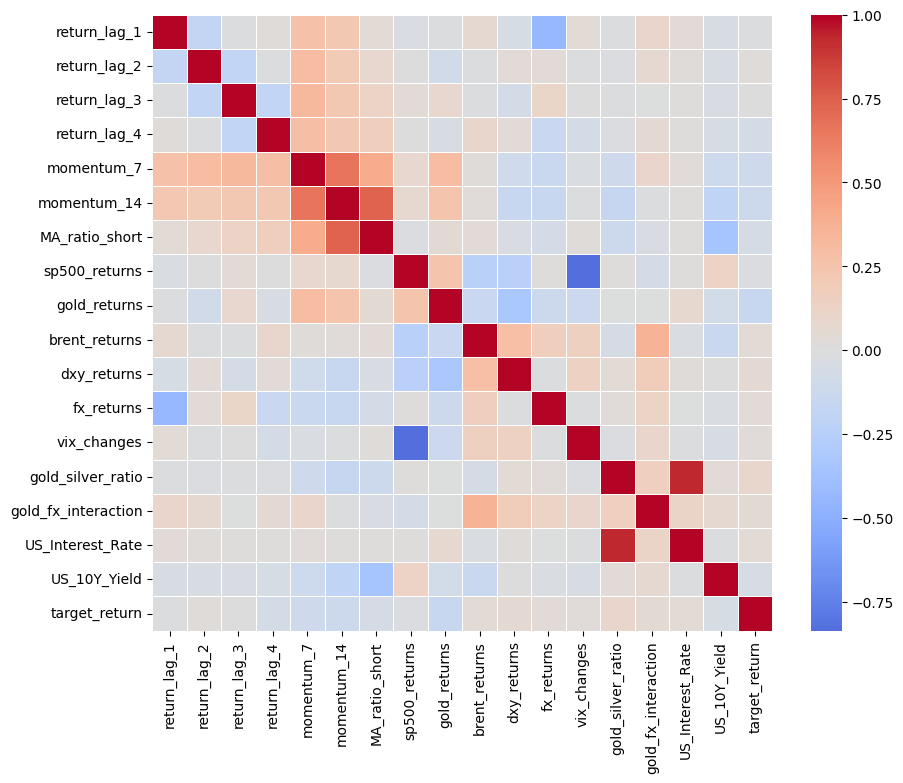

In [142]:
import seaborn as sns

Z=pd.concat([df[mean_features], df["target_return"]], axis=1)
# Step 1: Compute correlation matrix
corr_matrix = Z.corr()

# Step 2: Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,
            annot=False,        # show correlation values
            cmap="coolwarm",   # color palette
            center=0,          # center colormap at zero
            linewidths=0.5)    # grid lines between cells
plt.show()


In [123]:

mean_features = [
    *[f"return_lag_{i}" for i in range(1,5)],    
]


In [124]:

X_train = train[mean_features]
y_train = train["target_return"]

grid_return = GridSearchCV(
    estimator=XGBRegressor(objective="reg:squarederror",random_state=42),
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid_return.fit(X_train, y_train)
best_return_model = (grid_return.best_estimator_)

print(grid_return.best_params_)

print(-grid_return.best_score_) 



{'gamma': 0.5, 'lambda': 0, 'learning_rate': 0.01, 'max_depth': 1, 'min_child_weight': 0, 'n_estimators': 200}
0.029964327326109996


In [125]:
X_test = test[mean_features]
y_test = test["target_return"]

pred_return = best_return_model.predict(X_test)
mae_return = mean_absolute_error( y_test, pred_return )

print("Return MAE")
print(mae_return)

Return MAE
0.025303506498720266


### Volitility prediction

In [133]:
vol_features = [
    "volatility_7",
    "volatility_14",
    "volatility_ratio",
    "volatility_21",
    "volatility_63",
    "gold_vol_21",
    "sp500_vol_21",
    "fx_vol_21",
    "brent_vol_21",
    "vix_changes",
    "VIX",
    "US_10Y_Yield", 
]


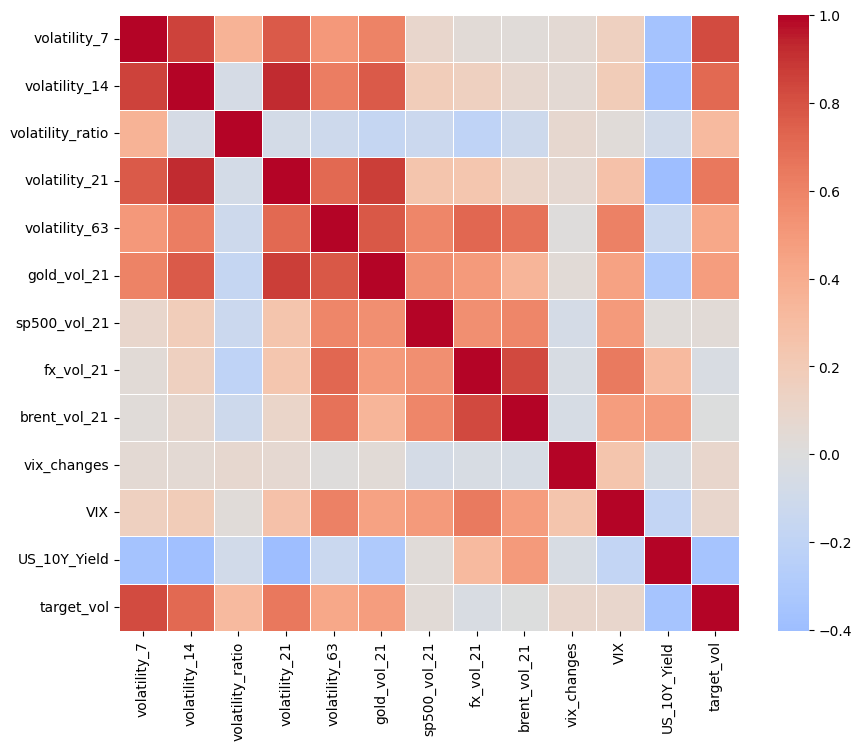

In [143]:
Z=pd.concat([df[vol_features], df["target_vol"]], axis=1)
# Step 1: Compute correlation matrix
corr_matrix = Z.corr()

# Step 2: Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,
            annot=False,        # show correlation values
            cmap="coolwarm",   # color palette
            center=0,          # center colormap at zero
            linewidths=0.5)    # grid lines between cells
plt.show()


In [129]:
vol_features = [
    "volatility_7",
    "volatility_14",
    "volatility_21",
    "volatility_63",
]


In [134]:
X_train = train[vol_features]
y_train_vol = train["target_vol"]

grid_vol = GridSearchCV(
    estimator=XGBRegressor(
        objective="reg:squarederror",
        random_state=42
    ),
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid_vol.fit(X_train,y_train_vol)
best_vol_model = grid_vol.best_estimator_
print(grid_vol.best_params_)
print(-grid_vol.best_score_) 


{'gamma': 0, 'lambda': 0, 'learning_rate': 0.01, 'max_depth': 1, 'min_child_weight': 1.5, 'n_estimators': 200}
0.013874355425031218


In [131]:

X_test = test[vol_features]
y_test_vol = test["target_vol"]

pred_vol = best_vol_model.predict(X_test)

mae_vol = mean_absolute_error(y_test_vol, pred_vol)

print("Volatility MAE")
print(mae_vol)

Volatility MAE
0.007347287934641799
